In [1]:
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('input_grafo.csv')
df_downgrades = df[
    df["evento_crediticio"] == "Downgrade"
]

In [3]:
df.head()

,source,periodo_mensual_A,target,evento_crediticio,weight
0,30500120882,2024-05,30509300700,Upgrade,0.301194
1,30500120882,2024-05,30525322749,Upgrade,0.165299
2,30500120882,2024-05,30525698412,Upgrade,0.135335
3,30500120882,2024-05,30526552659,Upgrade,0.301194
4,30500120882,2024-05,30576721710,Upgrade,0.449329


In [4]:
grafo_final_df = (
    df.groupby(["source", "target", "evento_crediticio"])
    .agg(
        weight=(
            "weight",
            "max",
        ),  # Máxima intensidad (reacción más rápida registrada)
        frecuencia=(
            "weight",
            "count",
        ),  # Cuántas veces en el histórico A precedió a B
    )
    .reset_index()
)

In [5]:
grafo_final_df['frecuencia'].value_counts()

frecuencia
1    2411
2     638
3     249
5      47
4      47
6       5
7       1
Name: count, dtype: int64

In [6]:
grafo_final_df.groupby('evento_crediticio')['source'].nunique()

evento_crediticio
Downgrade    49
Upgrade      69
Name: source, dtype: int64

In [7]:
grafo_final_df.groupby('evento_crediticio')['target'].nunique()

evento_crediticio
Downgrade    50
Upgrade      70
Name: target, dtype: int64

In [55]:
# 1. Creamos el grafo dirigido completamente vacío
G_dg = nx.DiGraph()

# 2. Filtramos tus Downgrades del DataFrame donde el weight está perfecto
df_final_downgrades = grafo_final_df[
    grafo_final_df["evento_crediticio"] == "Downgrade"
]

# 3. CONSTRUCCIÓN MANUAL: Inyectamos los nodos y aristas uno a uno asegurando los tipos
for _, fila in df_final_downgrades.iterrows():
    G_dg.add_edge(
        fila["source"],
        fila["target"],
        weight=float(fila["weight"]),  # <--- Forzamos el float numérico real
        frecuencia=int(fila["frecuencia"]),
    )

print(f"Grafo construido manualmente de forma segura.")
print(f"Nodos: {G_dg.number_of_nodes()} | Aristas: {G_dg.number_of_edges()}")

Grafo construido manualmente de forma segura.
Nodos: 50 | Aristas: 1246


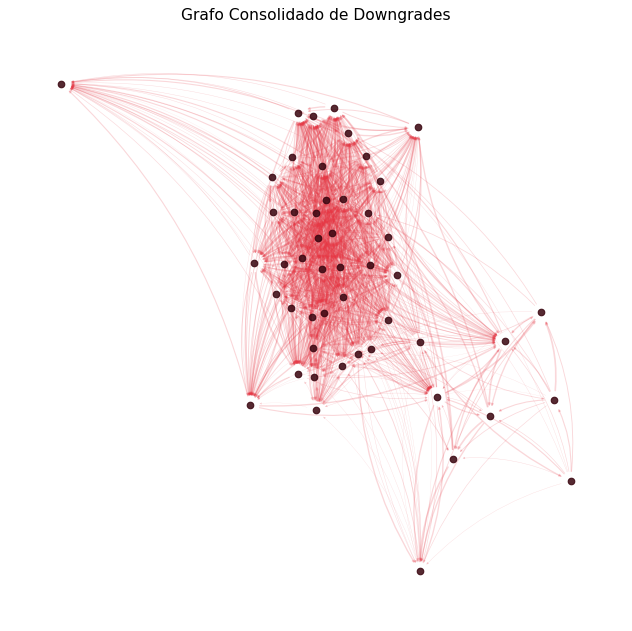

In [56]:
# 1. Lienzo grande para que la red tenga espacio para respirar
plt.figure(figsize=(8, 8), dpi=80)

# 2. CALCULAR RESORTES ESPACIADOS
# Subimos 'k' a 0.8 (por defecto es ~0.1). Esto fuerza a los nodos a separarse mucho más.
pos = nx.spring_layout(G_dg, k=0.5, iterations=100, seed=42)

# 3. Dibujar Nodos (tamaño equilibrado para que no tapen las flechas)
nx.draw_networkx_nodes(
    G_dg, pos, node_size=35, node_color="#38040e", alpha=0.85
)

# 4. Extraer grosores reales del weight
grosores = [G_dg[u][v]["weight"] * 1.8 for u, v in G_dg.edges()]

# 5. DIBUJAR ARISTAS CON CURVATURA
# 'connectionstyle="arc3,rad=0.15"' hace que las flechas tengan una leve curva,
# lo que evita que se superpongan si hay idas y vueltas o líneas cruzadas.
nx.draw_networkx_edges(
    G_dg,
    pos,
    arrowstyle="-|>",
    arrowsize=4,
    edge_color="#e63946",
    width=grosores,
    alpha=0.2,  # Opacidad justa para ver el trazo sin saturar
    connectionstyle="arc3,rad=0.15",
)

# 6. Etiquetas (Opcional): Si querés ver los CUITs de los 50 nodos encima del punto
# Descomentá la línea de abajo ajustando el tamaño de la letra
# nx.draw_networkx_labels(G_dg, pos, font_size=7, font_family="sans-serif", alpha=0.9)

plt.title(
    "Grafo Consolidado de Downgrades",
    fontsize=14,
    # fontweight="bold",
    # pad=15,
)
plt.axis("off")
plt.tight_layout()
plt.show()
plt.close()

In [39]:
# 1. Generar la matriz de adyacencia ponderada desde tu objeto G_dg
# Mapeamos explícitamente el atributo 'weight' para que rellene las celdas
matriz_adyacencia = nx.to_pandas_adjacency(G_dg, weight="weight")

# 2. Reemplazar los valores nulos si es necesario (NetworkX por defecto pone 0.0 donde no hay enlace)
matriz_adyacencia = matriz_adyacencia.fillna(0.0)

# --- CONTROL METODOLÓGICO PARA LA TESIS ---
print(f"Dimensiones de la matriz: {matriz_adyacencia.shape}")

Dimensiones de la matriz: (50, 50)


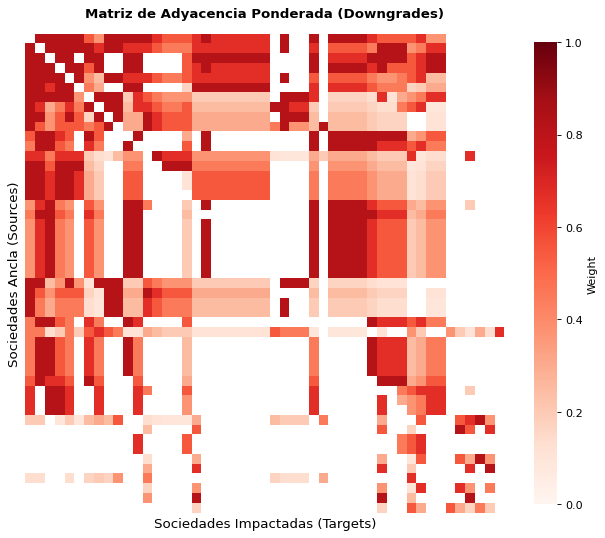

In [40]:

# 1. Opcional pero recomendado: Ordenar la matriz por intensidad de salida (Out-Degree)
# Esto agrupa las filas y columnas más activas para que el mapa tenga estructura
orden_sources = df_final_downgrades.groupby("source")["weight"].sum()
nodos_ordenados = orden_sources.sort_values(ascending=False).index
matriz_ordenada = matriz_adyacencia.reindex(
    index=nodos_ordenados, columns=nodos_ordenados, fill_value=0.0
)

# 2. CREAR LA MÁSCARA: Evaluamos dónde la matriz es exactamente igual a 0
# Seaborn OCULTA las celdas donde la máscara es True
mascara_ceros = matriz_ordenada == 0.0

# 3. Configurar el tamaño del lienzo
plt.figure(figsize=(8, 8), dpi=80)

# 4. Graficar el Heatmap con la máscara aplicada y la barra de color achicada
sns.heatmap(
    matriz_ordenada,
    mask=mascara_ceros,
    cmap="Reds",
    vmax=1.0,
    vmin=0.0,
    square=True,
    cbar_kws={
        "label": "Weight",
        "shrink": 0.75,  # <--- ACHICA LA BARRA (podes probar entre 0.6 y 0.8)
    },
    xticklabels=False,
    yticklabels=False,
)
# 5. Detalles estéticos
plt.title(
    "Matriz de Adyacencia Ponderada (Downgrades)",
    fontsize=12,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Sociedades Impactadas (Targets)", fontsize=12)
plt.ylabel("Sociedades Ancla (Sources)", fontsize=12)

plt.tight_layout()
plt.show()
plt.close()

In [41]:
# 1. Verificar la conectividad fuerte global
es_fuertemente_conexa = nx.is_strongly_connected(G_dg)

print("=" * 50)
print(f"¿La red de Downgrades es fuertemente conexa?: {es_fuertemente_conexa}")
print("=" * 50)

¿La red de Downgrades es fuertemente conexa?: False


Nodos en toda la red: 50
Enlaces en toda la red: 1246
Grado de Salida Medio: 24.92
Grado de Entrada Medio: 24.92
Clustering promedio Dirigido: 0.6590


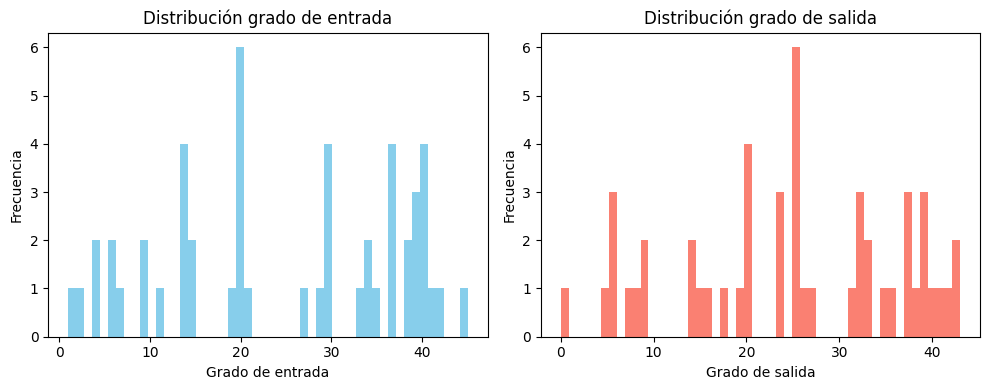

In [42]:
# ---------------------------------
# 2. Descripción del dataset (4a)
# ---------------------------------
# --- Medidas globales de la red completa ---
print(f"Nodos en toda la red: {G_dg.number_of_nodes()}")
print(f"Enlaces en toda la red: {G_dg.number_of_edges()}")

# 1. Grado de Salida Medio (Out-Degree): Cuántos impactos genera una empresa en promedio
out_grados = dict(G_dg.out_degree()).values()
out_grado_medio = sum(out_grados) / len(out_grados)

# 2. Grado de Entrada Medio (In-Degree): Cuántos impactos recibe una empresa en promedio
in_grados = dict(G_dg.in_degree()).values()
in_grado_medio = sum(in_grados) / len(in_grados)

print(f"Grado de Salida Medio: {out_grado_medio:.2f}")
print(f"Grado de Entrada Medio: {in_grado_medio:.2f}")

# 1. Clustering promedio DIRIGIDO (Fagiolo, 2007)
clustering_prom_dir = nx.average_clustering(G_dg)
print(f"Clustering promedio Dirigido: {clustering_prom_dir:.4f}")

plt.figure(figsize=(10,4))

plt.subplot(121)
plt.hist(in_grados, bins=50, color='skyblue')
plt.title('Distribución grado de entrada')
plt.xlabel('Grado de entrada')
plt.ylabel('Frecuencia')

plt.subplot(122)
plt.hist(out_grados, bins=50, color='salmon')
plt.title('Distribución grado de salida')
plt.xlabel('Grado de salida')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

In [43]:
# =====================================================================
# FUNCIÓN DE COMPARACIÓN ADAPTADA A REDES DIRIGIDAS
# =====================================================================
def compare_properties(graphs, labels):
    results = []
    for g, l in zip(graphs, labels):
        # Coeficiente de clustering dirigido nativo (Fagiolo, 2007)
        c_clustering = nx.average_clustering(g)

        # Distancia media adaptada a las restricciones de red dirigida
        try:
            if nx.is_strongly_connected(g):
                # Si es fuertemente conexo, calcula la distancia global real
                avg_path = nx.average_shortest_path_length(g)
            else:
                # Si no lo es (como los modelos teóricos), mide el núcleo central (SCC)
                componentes = max(nx.strongly_connected_components(g), key=len)
                subgrafo_nucleo = g.subgraph(componentes)

                if subgrafo_nucleo.number_of_nodes() > 1:
                    avg_path = nx.average_shortest_path_length(subgrafo_nucleo)
                else:
                    avg_path = np.nan
        except (nx.NetworkXError, nx.NetworkXNoPath):
            avg_path = np.nan

        results.append(
            {
                "Modelo": l,
                "C. clustering": c_clustering,
                "Distancia media": avg_path,
            }
        )
    return pd.DataFrame(results)

G_unweighted = nx.DiGraph(G_dg)

# =====================================================================
# 1. PARÁMETROS CORREGIDOS PARA RED DIRIGIDA
# =====================================================================
n = G_unweighted.number_of_nodes()
m = G_unweighted.number_of_edges()

# En redes dirigidas, el grado medio (sea Out o In) es simplemente m / n
k_avg_dirigido = m / n

# Parámetros para Holme-Kim (HK necesita estimar aristas no dirigidas base)
grado_promedio_total = sum(dict(G_unweighted.degree()).values()) / n
m_1 = max(1, int(grado_promedio_total / 4))

# =====================================================================
# 2. GENERACIÓN DE PROTOTIPOS TEÓRICOS DIRIGIDOS
# =====================================================================
# Erdős-Rényi: Le agregamos el parámetro directed=True
ER = nx.gnm_random_graph(n, m, directed=True, seed=42)

# Watts-Strogatz: El grado base (k) debe ser par. Lo aproximamos y convertimos a DiGraph
k_ws = int(k_avg_dirigido) if int(k_avg_dirigido) % 2 == 0 else int(k_avg_dirigido) + 1
k_ws = max(2, k_ws)
WS = nx.watts_strogatz_graph(n, k_ws, 0.1, seed=42).to_directed()

# Barabási-Albert: Para escala libre dirigida se usa scale_free_graph
BA_multigrafo = nx.scale_free_graph(n, alpha=0.41, beta=0.54, gamma=0.05, seed=42)
BA = nx.DiGraph(BA_multigrafo) # Lo pasamos a DiGraph simple
if BA.number_of_nodes() > n:   # Ajuste por consistencia de tamaño de muestra
    BA = BA.subgraph(list(G_unweighted.nodes()))

# Holme-Kim: Como no tiene versión dirigida nativa, lo generamos y lo convertimos
HK = nx.powerlaw_cluster_graph(n, m_1, 0.1, seed=42).to_directed()


# =====================================================================
# 3. CONSOLIDACIÓN DE MODELOS Y LLAMADA A LA FUNCIÓN
# =====================================================================
models = [G_unweighted, ER, WS, BA, HK]
labels = [
    "Grafo Downgrades",
    "Erdős-Rényi",
    "Watts-Strogatz",
    "Barabási-Albert",
    "Holme-Kim",
]

# Ahora sí, todos son DiGraph y la función va a correr perfecta
comparison_df = compare_properties(models, labels)

In [44]:
comparison_df

,Modelo,C. clustering,Distancia media
0,Grafo Downgrades,0.659049,1.529337
1,Erdős-Rényi,0.507853,1.491429
2,Watts-Strogatz,0.613843,1.511020
3,Barabási-Albert,0.035568,1.333333
4,Holme-Kim,0.430110,1.635102


Modularidad Louvain (Ponderada): 0.125
Número de comunidades detectadas: 3
Número de comunidades (Girvan-Newman): 2


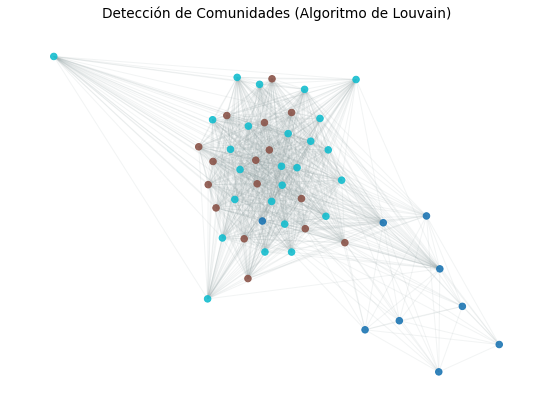

In [45]:
import community as community_louvain  # La librería python-louvain
import matplotlib.pyplot as plt
import networkx as nx
from networkx.algorithms.community import girvan_newman

# 1. Convertir a no dirigido (¡Conservando la estructura de tu red!)
# Usamos el nombre que traías en tus datos. Si se llama G_riesgo, cambialo acá:
G_undir = G_dg.to_undirected()

# 2. Algoritmo de Louvain PONDERADO (Pasamos el peso clave de IFRS 9)
partition = community_louvain.best_partition(G_undir, weight="weight")
modularity = community_louvain.modularity(partition, G_undir, weight="weight")

print("=" * 50)
print(f"Modularidad Louvain (Ponderada): {modularity:.3f}")
print(f"Número de comunidades detectadas: {len(set(partition.values()))}")
print("=" * 50)

# 3. Girvan-Newman (Ojo: es un algoritmo pesado, pero corre bien en 50 nodos)
comp = girvan_newman(G_undir)
comms = next(comp)
print(f"Número de comunidades (Girvan-Newman): {len(comms)}")

# 4. Visualización de las Comunidades sobre tu Layout de Resortes
plt.figure(figsize=(8, 6), dpi=70)

# Usamos la paleta 'tab10' o 'Set3' para que los colores de los clústeres sean bien claros
nx.draw_networkx_nodes(
    G_undir,
    pos,  # Usá el 'pos' de resortes expandido que calculamos antes
    node_size=45,
    node_color=list(partition.values()),
    cmap=plt.cm.tab10,
    alpha=0.9,
)

# Dibujamos los enlaces finitos para ver cómo se cruzan las fronteras de los clústeres
nx.draw_networkx_edges(G_undir, pos, alpha=0.12, edge_color="#95a5a6")

plt.title(
    "Detección de Comunidades (Algoritmo de Louvain)",
    fontsize=14,
    # fontweight="bold",
    # pad=15,
)
plt.axis("off")
plt.tight_layout()
plt.show()
plt.close()

Nodos: 50 | Aristas: 2030


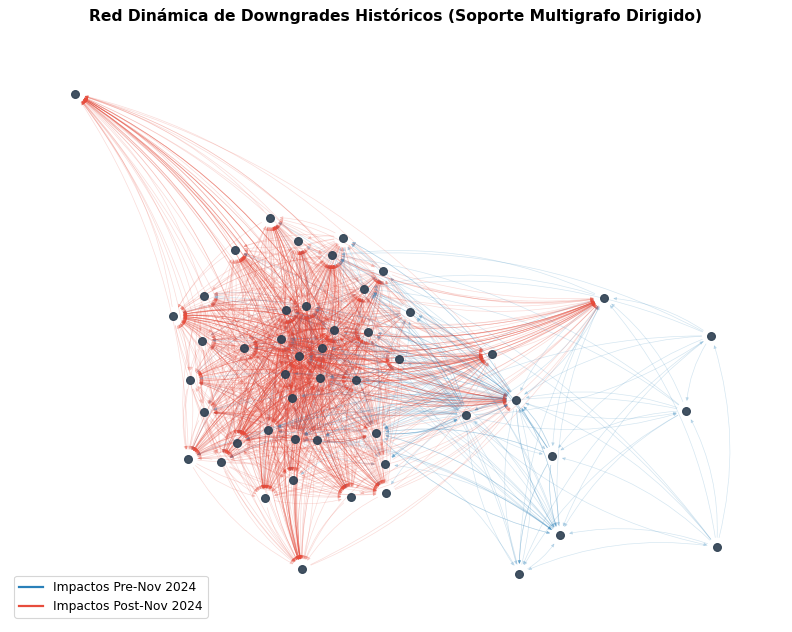

In [84]:
import matplotlib.pyplot as plt
import networkx as nx

# 1. Crear el MULTIGRAFO DIRIGIDO (Soporta múltiples flechas A -> B)
# Pasamos directamente tu DataFrame 'df' sin agrupar
G_multi = nx.from_pandas_edgelist(
    df_downgrades,
    source="source",
    target="target",
    edge_attr=["weight", "periodo_mensual_A", "evento_crediticio"],
    create_using=nx.MultiDiGraph(),  # <--- CLAVE: Estructura MultiDiGraph
)

# 2. Clasificar los múltiples enlaces por época
edge_colors = []
# En un MultiDiGraph, el bucle devuelve u, v, clave_arista, data
for u, v, k, data in G_multi.edges(keys=True, data=True):
    fecha = data.get("periodo_mensual_A")

    if int(str(fecha).replace("-", "")[:6]) < 202411:
        edge_colors.append("#2980b9")  # Época 1: Azul
    else:
        edge_colors.append("#e74c3c")  # Época 2: Rojo

# 3. Clasificar los nodos por su primera aparición histórica
node_colors = []
for nodo in G_multi.nodes():
    fechas_nodo = []
    for u, v, k, data in G_multi.edges(nodo, keys=True, data=True):
        fechas_nodo.append(int(str(data.get("periodo_mensual_A")).replace("-", "")[:6]))

    if fechas_nodo and min(fechas_nodo) < 202411:
        node_colors.append("#34495e")  # Actor Temprano
    else:
        node_colors.append("#e67e22")  # Actor Tardío

print(f"Nodos: {G_multi.number_of_nodes()} | Aristas: {G_multi.number_of_edges()}")

# =====================================================================
# 4. VISUALIZACIÓN DEL MULTIGRAFO
# =====================================================================
plt.figure(figsize=(10, 8), dpi=80)

pos_multi = nx.spring_layout(G_multi, k=0.5, seed=42) # Usamos un alias pos_multi

# Dibujamos los nodos usando tu 'pos' de resortes global
nx.draw_networkx_nodes(
    G_multi, pos_multi, node_size=50, node_color="#2c3e50", alpha=0.9
)

# Dibujamos las aristas.
# REGLA CRÍTICA: connectionstyle=f"arc3,rad={...}" es OBLIGATORIO en MultiDiGraph
# para que las flechas repetidas se abran y no se tapen entre sí.
nx.draw_networkx_edges(
    G_multi,
    pos_multi,
    edge_color=edge_colors,
    width=0.6,
    alpha=0.2,
    arrowsize=6,
    connectionstyle="arc3,rad=0.15",  # Curvatura para separar los múltiples enlaces
)

# Leyenda y títulos
proxies = [
    plt.Line2D([0], [0], color="#2980b9", lw=2),
    plt.Line2D([0], [0], color="#e74c3c", lw=2),
]
plt.legend(
    proxies,
    ["Impactos Pre-Nov 2024", "Impactos Post-Nov 2024"],
    loc="lower left",
    frameon=True,
    fontsize=11,
)
plt.title(
    "Red Dinámica de Downgrades Históricos (Soporte Multigrafo Dirigido)",
    fontsize=14,
    fontweight="bold",
    pad=20,
)
plt.axis("off")
plt.tight_layout()
plt.show()

In [68]:
# 1. Generar la matriz de adyacencia ponderada desde tu objeto G_dg
# Mapeamos explícitamente el atributo 'weight' para que rellene las celdas
matriz_adyacencia = nx.to_pandas_adjacency(G_multi, weight="weight")

# 2. Reemplazar los valores nulos si es necesario (NetworkX por defecto pone 0.0 donde no hay enlace)
matriz_adyacencia = matriz_adyacencia.fillna(0.0)

# --- CONTROL METODOLÓGICO PARA LA TESIS ---
print(f"Dimensiones de la matriz: {matriz_adyacencia.shape}")

Dimensiones de la matriz: (50, 50)


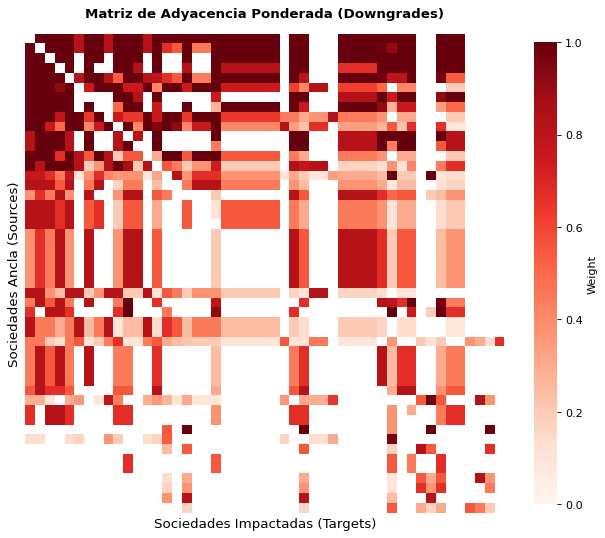

In [69]:

# 1. Opcional pero recomendado: Ordenar la matriz por intensidad de salida (Out-Degree)
# Esto agrupa las filas y columnas más activas para que el mapa tenga estructura
orden_sources = df_downgrades.groupby("source")["weight"].sum()
nodos_ordenados = orden_sources.sort_values(ascending=False).index
matriz_ordenada = matriz_adyacencia.reindex(
    index=nodos_ordenados, columns=nodos_ordenados, fill_value=0.0
)

# 2. CREAR LA MÁSCARA: Evaluamos dónde la matriz es exactamente igual a 0
# Seaborn OCULTA las celdas donde la máscara es True
mascara_ceros = matriz_ordenada == 0.0

# 3. Configurar el tamaño del lienzo
plt.figure(figsize=(8, 8), dpi=80)

# 4. Graficar el Heatmap con la máscara aplicada y la barra de color achicada
sns.heatmap(
    matriz_ordenada,
    mask=mascara_ceros,
    cmap="Reds",
    vmax=1.0,
    vmin=0.0,
    square=True,
    cbar_kws={
        "label": "Weight",
        "shrink": 0.75,  # <--- ACHICA LA BARRA (podes probar entre 0.6 y 0.8)
    },
    xticklabels=False,
    yticklabels=False,
)
# 5. Detalles estéticos
plt.title(
    "Matriz de Adyacencia Ponderada (Downgrades)",
    fontsize=12,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Sociedades Impactadas (Targets)", fontsize=12)
plt.ylabel("Sociedades Ancla (Sources)", fontsize=12)

plt.tight_layout()
plt.show()
plt.close()

In [70]:
# 1. Verificar la conectividad fuerte global
es_fuertemente_conexa = nx.is_strongly_connected(G_multi)

print("=" * 50)
print(f"¿La red de Downgrades es fuertemente conexa?: {es_fuertemente_conexa}")
print("=" * 50)

¿La red de Downgrades es fuertemente conexa?: False


Nodos en toda la red: 50
Enlaces en toda la red (Eventos totales): 2030
Grado de Salida Medio: 40.60
Grado de Entrada Medio: 40.60
Clustering promedio Dirigido (Fagiolo, 2007): 0.6590


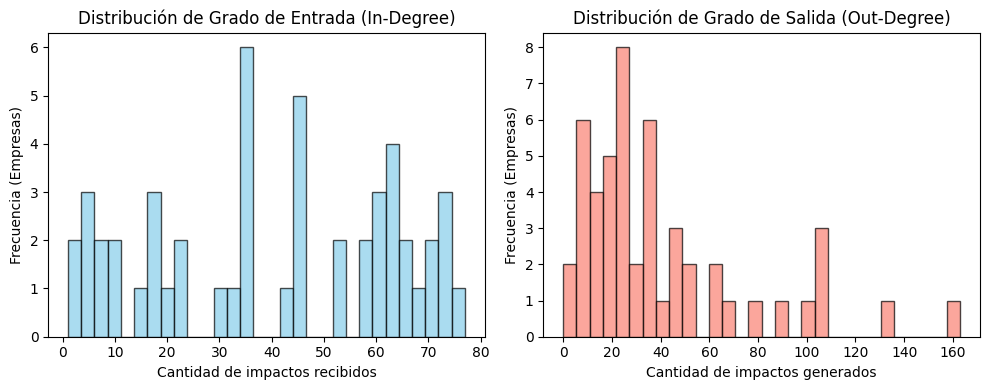

In [72]:
# ---------------------------------------------------------------------
# 2. Descripción del dataset (Métricas estructurales sobre Multigrafo)
# ---------------------------------------------------------------------
print(f"Nodos en toda la red: {G_multi.number_of_nodes()}")
print(f"Enlaces en toda la red (Eventos totales): {G_multi.number_of_edges()}")

# 1. Grado de Salida Medio (Out-Degree): Cuántos impactos genera una empresa en promedio
out_grados = dict(G_multi.out_degree()).values()
out_grado_medio = sum(out_grados) / len(out_grados)

# 2. Grado de Entrada Medio (In-Degree): Cuántos impactos recibe una empresa en promedio
in_grados = dict(G_multi.in_degree()).values()
in_grado_medio = sum(in_grados) / len(in_grados)

print(f"Grado de Salida Medio: {out_grado_medio:.2f}")
print(f"Grado de Entrada Medio: {in_grado_medio:.2f}")

# =====================================================================
# CORRECCIÓN SOLUCIÓN: Clustering Promedio DIRIGIDO (Fagiolo, 2007)
# Se calcula sobre el grafo dirigido simple para evitar la redundancia temporal
# =====================================================================
G_simple = nx.DiGraph(G_multi)

clustering_prom_dir = nx.average_clustering(G_simple)
print(f"Clustering promedio Dirigido (Fagiolo, 2007): {clustering_prom_dir:.4f}")

# ---------------------------------------------------------------------
# Visualización de las Distribuciones de Grado
# ---------------------------------------------------------------------
plt.figure(figsize=(10, 4))

plt.subplot(121)
plt.hist(in_grados, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Distribución de Grado de Entrada (In-Degree)')
plt.xlabel('Cantidad de impactos recibidos')
plt.ylabel('Frecuencia (Empresas)')

plt.subplot(122)
plt.hist(out_grados, bins=30, color='salmon', edgecolor='black', alpha=0.7)
plt.title('Distribución de Grado de Salida (Out-Degree)')
plt.xlabel('Cantidad de impactos generados')
plt.ylabel('Frecuencia (Empresas)')

plt.tight_layout()
plt.show()

In [192]:
# =====================================================================
# 1. GENERACIÓN DE LA RED EMPÍRICA BASE (SIMPLE Y SIN PESOS)
# =====================================================================
# Colapsamos el G_multi (que ya tiene solo downgrades) a un DiGraph simple.
# Esto consolida las ráfagas temporales en canales únicos de transmisión.
# G_simple = nx.DiGraph(G_multi)

n = G_simple.number_of_nodes()
m = G_simple.number_of_edges()

# En redes dirigidas simples, el grado medio estructural es m / n (~24)
k_avg_dirigido = m / n

# # Parámetros para Holme-Kim (Aproximación para conservar consistencia en el volumen de aristas)
# grado_promedio_total = sum(dict(G_simple.degree()).values()) / n
# m_1 = max(1, int(grado_promedio_total / 4))


# =====================================================================
# 2. GENERACIÓN DE PROTOTIPOS TEÓRICOS DIRIGIDOS
# =====================================================================
# Erdős-Rényi (Modelo Nulo Estructural)
ER = nx.gnm_random_graph(n, m, directed=True, seed=42)

# Watts-Strogatz (Mundo Pequeño Dirigido)
k_ws = int(k_avg_dirigido) if int(k_avg_dirigido) % 2 == 0 else int(k_avg_dirigido) + 1
k_ws = max(2, k_ws)
WS = nx.watts_strogatz_graph(n, k_ws, 0.1, seed=42).to_directed()

# Barabási-Albert (Escala Libre Dirigida)
BA_grafo= nx.scale_free_graph(n, alpha=0.41, beta=0.54, gamma=0.05, seed=42)
BA = nx.DiGraph(BA_grafo)
if BA.number_of_nodes() > n:
    BA = BA.subgraph(list(G_simple.nodes()))

# Holme-Kim (Estructura de Clústeres Dirigida)
# HK = nx.powerlaw_cluster_graph(n, m_1, 0.1, seed=42).to_directed()

# =====================================================================
# 3. EJECUCIÓN DE LA COMPARACIÓN METODOLÓGICA
# =====================================================================
models = [G_simple, ER, WS, BA, HK]
labels = [
    "Grafo Downgrades (Simple)",
    "Erdős-Rényi",
    "Watts-Strogatz",
    "Barabási-Albert",
    # "Holme-Kim",
]

# La función compare_properties ahora procesa la red purificada de downgrades
comparison_df = compare_properties(models, labels)

# Mostramos el DataFrame final para copiar directo a LaTeX
print("\n" + "="*50)
print("TABLA DE COMPARACIÓN TOPOLÓGICA GENERAL (SÓLO DOWNGRADES)")
print("="*50)
print(comparison_df.to_string(index=False))
print("="*50)


TABLA DE COMPARACIÓN TOPOLÓGICA GENERAL (SÓLO DOWNGRADES)
                   Modelo  C. clustering  Distancia media
Grafo Downgrades (Simple)       0.659049         1.529337
              Erdős-Rényi       0.507853         1.491429
           Watts-Strogatz       0.613843         1.511020
          Barabási-Albert       0.035568         1.333333


ANÁLISIS DE COMUNIDADES ESTRUCTURALES (SÓLO DOWNGRADES)
Modularidad Louvain (Ponderada por Intensidad): 0.122
Número de comunidades detectadas (Louvain): 3
Número de comunidades (Girvan-Newman): 2


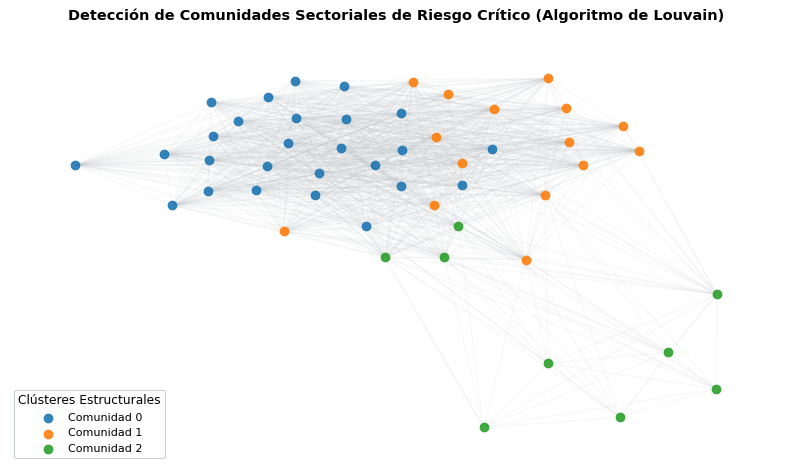

In [166]:
# =====================================================================
# 1. PREPARACIÓN DE LA RED: CONVERSIÓN DIRECTA DESDE TU GRAFO LIMPIO
# =====================================================================
# Como G_dg ya tiene solo downgrades y los pesos máximos/consolidados,
# simplemente lo pasamos a no dirigido para Louvain.
G_undir = G_simple.to_undirected()

# =====================================================================
# 2. EJECUCIÓN DE LOUVAIN PONDERADO
# =====================================================================
partition = community_louvain.best_partition(G_undir, weight="weight", random_state=42)
modularity = community_louvain.modularity(partition, G_undir, weight="weight")

print("=" * 60)
print("ANÁLISIS DE COMUNIDADES ESTRUCTURALES (SÓLO DOWNGRADES)")
print("=" * 60)
print(f"Modularidad Louvain (Ponderada por Intensidad): {modularity:.3f}")
print(f"Número de comunidades detectadas (Louvain): {len(set(partition.values()))}")

# =====================================================================
# 3. GIRVAN-NEWMAN DE CONTROL
# =====================================================================
comp = girvan_newman(G_undir)
comms = next(comp)
print(f"Número de comunidades (Girvan-Newman): {len(comms)}")
print("=" * 60)

# =====================================================================
# 4. VISUALIZACIÓN DE LAS COMUNIDADES (CON LEYENDA AUTOMÁTICA)
# =====================================================================
plt.figure(figsize=(10, 6), dpi=80) # Ajusté un poco el tamaño para darle aire a la leyenda

# 4.1 Calculamos el layout de resortes (k=0.5 para dispersar el núcleo)
pos_comunidades = nx.spring_layout(G_undir, k=0.5, seed=42)

# 4.2 Enlaces suavizados de fondo
nx.draw_networkx_edges(
    G_undir,
    pos_comunidades,
    alpha=0.12,
    edge_color="#bdc3c7"
)

# 4.3 Dibujamos los nodos COMUNIDAD POR COMUNIDAD para poder etiquetarlos
lista_comunidades = sorted(list(set(partition.values())))
mapa_colores = plt.cm.tab10  # Paleta categórica

for i, com_id in enumerate(lista_comunidades):
    # Filtramos las empresas que pertenecen a la comunidad actual
    nodos_comunidad = [nodo for nodo, com in partition.items() if com == com_id]

    # Dibujamos solo este grupo de puntos asignándole su color correspondiente
    nx.draw_networkx_nodes(
        G_undir,
        pos_comunidades,
        nodelist=nodos_comunidad,
        node_size=60,
        node_color=[mapa_colores(i)],  # Asigna el color fijo de la paleta
        alpha=0.9,
        label=f"Comunidad {com_id}"    # <--- CLAVE: Etiqueta para la leyenda
    )

# 4.4 Agregamos la leyenda de Matplotlib
plt.legend(
    title="Clústeres Estructurales",
    title_fontsize=11,
    fontsize=10,
    loc="lower left",      # Ubicación clásica
    frameon=True,          # Recuadro contenedor
    shadow=False,
    facecolor="white",
    edgecolor="#bdc3c7"
)

plt.title(
    "Detección de Comunidades Sectoriales de Riesgo Crítico (Algoritmo de Louvain)",
    fontsize=13,
    fontweight="bold",
    pad=20,
)
plt.axis("off")
plt.tight_layout()

# Guardamos el archivo listo para insertar en LaTeX
plt.savefig("downgrades_comunidades_louvain.pdf", bbox_inches="tight", dpi=300)
plt.show()

In [124]:
actividades = pd.read_csv("/Users/sofiascaiano/Documents/maestria/TT1/project/actividad_afip/data/output/actividades_economicas.csv")
actividades = actividades[actividades['es_actividad_principal'] == 1]
actividades['id_actividad'] = actividades['id_actividad'].astype(str).str.zfill(6)
actividades['grupo'] = actividades['id_actividad'].str[:2]
actividades['subgrupo'] = actividades['id_actividad'].str[:3]
clae = pd.read_csv("/Users/sofiascaiano/Documents/maestria/TT1/project/actividad_afip/data/output/clae_afip.csv")
clae['grupo'] = clae['grupo'].astype('Int64').astype(str).str.zfill(2)
clae['subgrupo'] = clae['subgrupo'].astype('Int64').astype(str).str.zfill(3)

In [128]:
actividades_2 = pd.merge(actividades, clae[clae['subgrupo'].isna()][['grupo', 'seccion', 'descripcion']], on='grupo', how='left', suffixes=('', '_grupo'))

actividades_3 = pd.merge(actividades_2, clae[~clae['subgrupo'].isna()][['subgrupo', 'descripcion']], on='subgrupo', how='left', suffixes=('', '_subgrupo'))

actividades_4 = pd.merge(actividades_3, clae[clae['grupo'].isna()][['seccion', 'descripcion']], on='seccion', how='left', suffixes=('', '_seccion'))

actividades_final = actividades_4[['cuit_consultado', 'id_actividad', 'descripcion', 'seccion', 'descripcion_grupo', 'descripcion_subgrupo', 'descripcion_seccion']]
actividades_final.columns = ['cuit', 'id_actividad', 'descripcion_actividad', 'seccion', 'descripcion_grupo', 'descripcion_subgrupo', 'descripcion_seccion']

In [147]:
actividades_final.descripcion_seccion.value_counts(dropna=False)

descripcion_seccion
INDUSTRIA MANUFACTURERA                                                                     52
SUMINISTRO DE ELECTRICIDAD, GAS, VAPOR Y AIRE ACONDICIONADO                                 25
EXPLOTACIÓN DE MINAS Y CANTERAS                                                             21
COMERCIO AL POR MAYOR Y AL POR MENOR; REPARACIÓN DE VEHÍCULOS AUTOMOTORES Y MOTOCICLETAS    15
SERVICIOS FINANCIEROS Y DE SEGUROS                                                          12
AGRICULTURA, GANADERÍA, CAZA, SILVICULTURA Y PESCA                                          11
CONSTRUCCIÓN                                                                                 7
INFORMACIÓN Y COMUNICACIONES                                                                 6
SERVICIO DE TRANSPORTE Y ALMACENAMIENTO                                                      4
SERVICIOS INMOBILIARIOS                                                                      3
SERVICIOS PROFESIONALES, CIENT

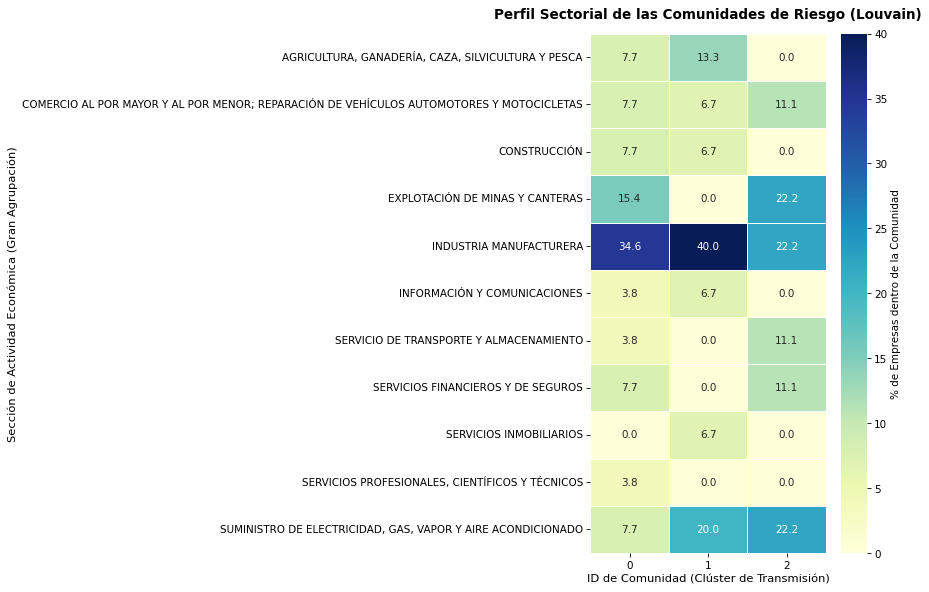

In [155]:

# =====================================================================
# 1. PREPARACIÓN DE LOS DATOS: MAPEADO DE COMUNIDADES
# =====================================================================
# Convertimos el diccionario de la partición de Louvain a un DataFrame limpio
df_louvain = pd.DataFrame(list(partition.items()), columns=['cuit', 'comunidad'])

# Aseguramos que el CUIT sea del mismo tipo en ambos DataFrames antes del merge
df_louvain['cuit'] = df_louvain['cuit'].astype(str)
actividades_final['cuit'] = actividades_final['cuit'].astype(str)

# Cruzamos la partición de la red con tu listado de actividades declaradas
df_analisis = df_louvain.merge(actividades_final, on='cuit', how='left')

# Rellenamos nulos por si alguna empresa de la red no tenía actividad declarada
df_analisis['descripcion_seccion'] = df_analisis['descripcion_seccion'].fillna('Sin Especificar')

# =====================================================================
# 2. MATRIZ DE CONTINGENCIA (Frecuencias absolutas y relativas)
# =====================================================================
# Contamos cuántas empresas de cada sector cayeron en cada comunidad
matriz_contingencia = pd.crosstab(
    df_analisis['descripcion_seccion'],
    df_analisis['comunidad'],
    margins=True,
    margins_name="Total General"
)

# Calculamos los porcentajes por columna (Composición interna de cada comunidad)
# Te dice: "De la Comunidad 0, el X% pertenece al Agro, el Y% a Industria..."
matriz_porcentajes = pd.crosstab(
    df_analisis['descripcion_seccion'],
    df_analisis['comunidad'],
    normalize='columns'
) * 100

# print("="*60)
# print("COMPOSICIÓN SECTORIAL POR COMUNIDAD (% SOBRE EL TOTAL DEL CLÚSTER)")
# print("="*60)
# print(matriz_porcentajes.round(1).to_string())
# print("="*60)

# =====================================================================
# 3. VISUALIZACIÓN EN UN HEATMAP (Ideal para meter en la Tesis)
# =====================================================================
plt.figure(figsize=(12, 8), dpi=75)
sns.heatmap(
    matriz_porcentajes,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    linewidths=0.5,
    cbar_kws={'label': '% de Empresas dentro de la Comunidad'}
)

plt.title("Perfil Sectorial de las Comunidades de Riesgo (Louvain)", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("ID de Comunidad (Clúster de Transmisión)", fontsize=11)
plt.ylabel("Sección de Actividad Económica (Gran Agrupación)", fontsize=11)
plt.tight_layout()

# Guardamos el PDF de alta calidad
# plt.savefig("composicion_sectorial_louvain.pdf", bbox_inches="tight", dpi=300)
plt.show()

In [170]:
nodos = list(G_multi.nodes())
N = len(nodos)
node_to_idx = {nodo: idx for idx, nodo in enumerate(nodos)}

# 1. Matriz de Adyacencia Ponderada a partir del Multigrafo
A = np.zeros((N, N))

# Recorremos todas las aristas temporales. Si hay repetidas entre u y v,
# se suman automáticamente acumulando la fuerza del contagio histórico.
for u, v, data in G_multi.edges(data=True):
    idx_u = node_to_idx[u]
    idx_v = node_to_idx[v]
    A[idx_u][idx_v] += data.get('weight', 1.0)

# Normalizamos por el In-Degree total (frecuencia de impactos recibidos por j)
col_sums = A.sum(axis=0, keepdims=True)
P = np.divide(A, col_sums, out=np.zeros_like(A), where=col_sums!=0)

In [176]:
G_multi.edges(data=True)

OutMultiEdgeDataView([(30500179151, 30501062150, {'weight': 0.6703200460356393, 'periodo_mensual_A': '2025-07', 'evento_crediticio': 'Downgrade'}), (30500179151, 30502112259, {'weight': 0.8187307530779818, 'periodo_mensual_A': '2025-07', 'evento_crediticio': 'Downgrade'}), (30500179151, 30511190238, {'weight': 0.5488116360940264, 'periodo_mensual_A': '2025-07', 'evento_crediticio': 'Downgrade'}), (30500179151, 30593174057, {'weight': 0.8187307530779818, 'periodo_mensual_A': '2025-07', 'evento_crediticio': 'Downgrade'}), (30500179151, 30629827060, {'weight': 0.2465969639416064, 'periodo_mensual_A': '2025-07', 'evento_crediticio': 'Downgrade'}), (30500179151, 30637695335, {'weight': 0.3678794411714423, 'periodo_mensual_A': '2025-07', 'evento_crediticio': 'Downgrade'}), (30500179151, 30646167775, {'weight': 0.2018965179946553, 'periodo_mensual_A': '2025-07', 'evento_crediticio': 'Downgrade'}), (30500179151, 30651863658, {'weight': 0.8187307530779818, 'periodo_mensual_A': '2025-07', 'event

In [175]:
A

array([[0.        , 0.67032005, 0.81873075, ..., 0.        , 0.        ,
        0.        ],
       [1.46572865, 0.        , 2.4191688 , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.81873075, 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.81873075,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.54881164, 0.44932896,
        0.        ]], shape=(50, 50))

In [174]:
col_sums

array([[13.92310226, 37.7866525 , 31.92870745, 31.57589213, 39.74096095,
        21.80912381, 20.40707906, 25.31164417, 21.14976746, 24.61026824,
        23.42410646, 36.44612886, 22.92914055, 29.85793183, 20.40707906,
        21.14976746, 21.14976746, 25.67295887, 29.47898657, 34.45743431,
        15.92216136, 38.97399527, 21.14976746, 24.8561643 , 20.5130165 ,
        38.80219988,  4.46238842, 13.92310226,  9.59100392, 13.92310226,
        10.63768105, 11.70087119, 13.92310226, 17.75614624, 10.71447864,
        15.12363564,  9.59100392, 13.92310226, 13.92310226, 17.55816725,
        11.01223444,  3.68169049,  6.02680608,  2.45037352,  4.46238842,
         2.10838225,  3.0897648 ,  0.91669108,  2.38798468,  0.67032005]])

In [186]:
np.where(P ==1)

(array([45]), array([49]))

In [168]:
import numpy as np
import pandas as pd
import networkx as nx

def calcular_debtrank_multigrafo(G_multi):
    """
    Calcula el DebtRank adaptado al Objetivo 4.4 usando el Multigrafo histórico.
    El estrés se propaga acumulando la frecuencia e intensidad de los enlaces temporales.
    """
    nodos = list(G_multi.nodes())
    N = len(nodos)
    node_to_idx = {nodo: idx for idx, nodo in enumerate(nodos)}

    # 1. Matriz de Adyacencia Ponderada a partir del Multigrafo
    A = np.zeros((N, N))

    # Recorremos todas las aristas temporales. Si hay repetidas entre u y v,
    # se suman automáticamente acumulando la fuerza del contagio histórico.
    for u, v, data in G_multi.edges(data=True):
        idx_u = node_to_idx[u]
        idx_v = node_to_idx[v]
        A[idx_u][idx_v] += data.get('weight', 1.0)

    # Normalizamos por el In-Degree total (frecuencia de impactos recibidos por j)
    col_sums = A.sum(axis=0, keepdims=True)
    P = np.divide(A, col_sums, out=np.zeros_like(A), where=col_sums!=0)

    resultados_dr = {}

    # 2. Simulación Dinámica del Efecto Dominó (Shock individual por CUIT)
    for nodo_shock in nodos:
        idx_shock = node_to_idx[nodo_shock]

        # Vector de estrés h(t) de cada empresa (de 0 a 1)
        h = np.zeros(N)
        h[idx_shock] = 1.0  # Gatillo: Ocurrencia del downgrade inicial

        # Monitoreo de Estados (Sane=0, Distressed=1, Inactive=2)
        estado = np.zeros(N)
        estado[idx_shock] = 1

        paso = 0
        while np.any(estado == 1) and paso < N:
            activos = (estado == 1)
            nuevos_estreses = np.zeros(N)

            for j in range(N):
                if estado[j] == 0:  # Solo contagiamos a nodos que siguen "sanos"
                    # El estrés se transmite en función del peso acumulado en el multigrafo
                    impacto_acumulado = sum(h[i] * P[i][j] for i in range(N) if activos[i])
                    if impacto_acumulado > 0:
                        nuevos_estreses[j] = min(1.0, impacto_acumulado)

            # Transición de estados: los activos se apagan tras propagar su estrés
            estado[activos] = 2

            # Los alcanzados por el shock entran en estado crítico para la próxima ronda
            infectados_ronda = (nuevos_estreses > 0)
            estado[infectados_ronda] = 1
            h[infectados_ronda] = nuevos_estreses[infectados_ronda]

            paso += 1

        # Cuantificación del impacto neto en el resto de la red corporativa
        score_debtrank = sum(h) - 1.0

        # Lo expresamos como el % del mercado total que se degrada por culpa de este nodo
        resultados_dr[nodo_shock] = (score_debtrank / (N - 1)) * 100

    return resultados_dr

# =====================================================================
# EJECUCIÓN DIRECTA SOBRE TU MULTIGRAFO HISTÓRICO
# =====================================================================
scores_debtrank = calcular_debtrank_multigrafo(G_multi)

# Consolidamos el ranking en tu DataFrame de resultados
df_debtrank = pd.DataFrame(list(scores_debtrank.items()), columns=['cuit', 'DebtRank_Porcentaje'])

# Cruce con las actividades declaradas de AFIP/CLAE
df_debtrank['cuit'] = df_debtrank['cuit'].astype(str)
actividades_final['cuit'] = actividades_final['cuit'].astype(str)
df_debtrank_final = df_debtrank.merge(actividades_final, on='cuit', how='left').sort_values(by='DebtRank_Porcentaje', ascending=False)

print("\n" + "="*75)
print("RANKING DE IMPACTO SISTÉMICO VÍA DEBTRANK (SOBRE ENLACES TEMPORALES)")
print("="*75)
print(df_debtrank_final[['cuit', 'DebtRank_Porcentaje', 'descripcion_seccion']].head(10).to_string(index=False))
print("="*75)


RANKING DE IMPACTO SISTÉMICO VÍA DEBTRANK (SOBRE ENLACES TEMPORALES)
       cuit  DebtRank_Porcentaje                                                                      descripcion_seccion
33711944899             7.721991                              SUMINISTRO DE ELECTRICIDAD, GAS, VAPOR Y AIRE ACONDICIONADO
30501062150             6.439637                                                                  INDUSTRIA MANUFACTURERA
30592724541             6.319659                                                                  INDUSTRIA MANUFACTURERA
30682434720             5.807197                              SUMINISTRO DE ELECTRICIDAD, GAS, VAPOR Y AIRE ACONDICIONADO
30589527115             5.527064                                                                  INDUSTRIA MANUFACTURERA
30714814229             5.333608                                                          EXPLOTACIÓN DE MINAS Y CANTERAS
30999027489             5.272752                              SUMINISTRO DE 

In [169]:
P

NameError: name 'P' is not defined

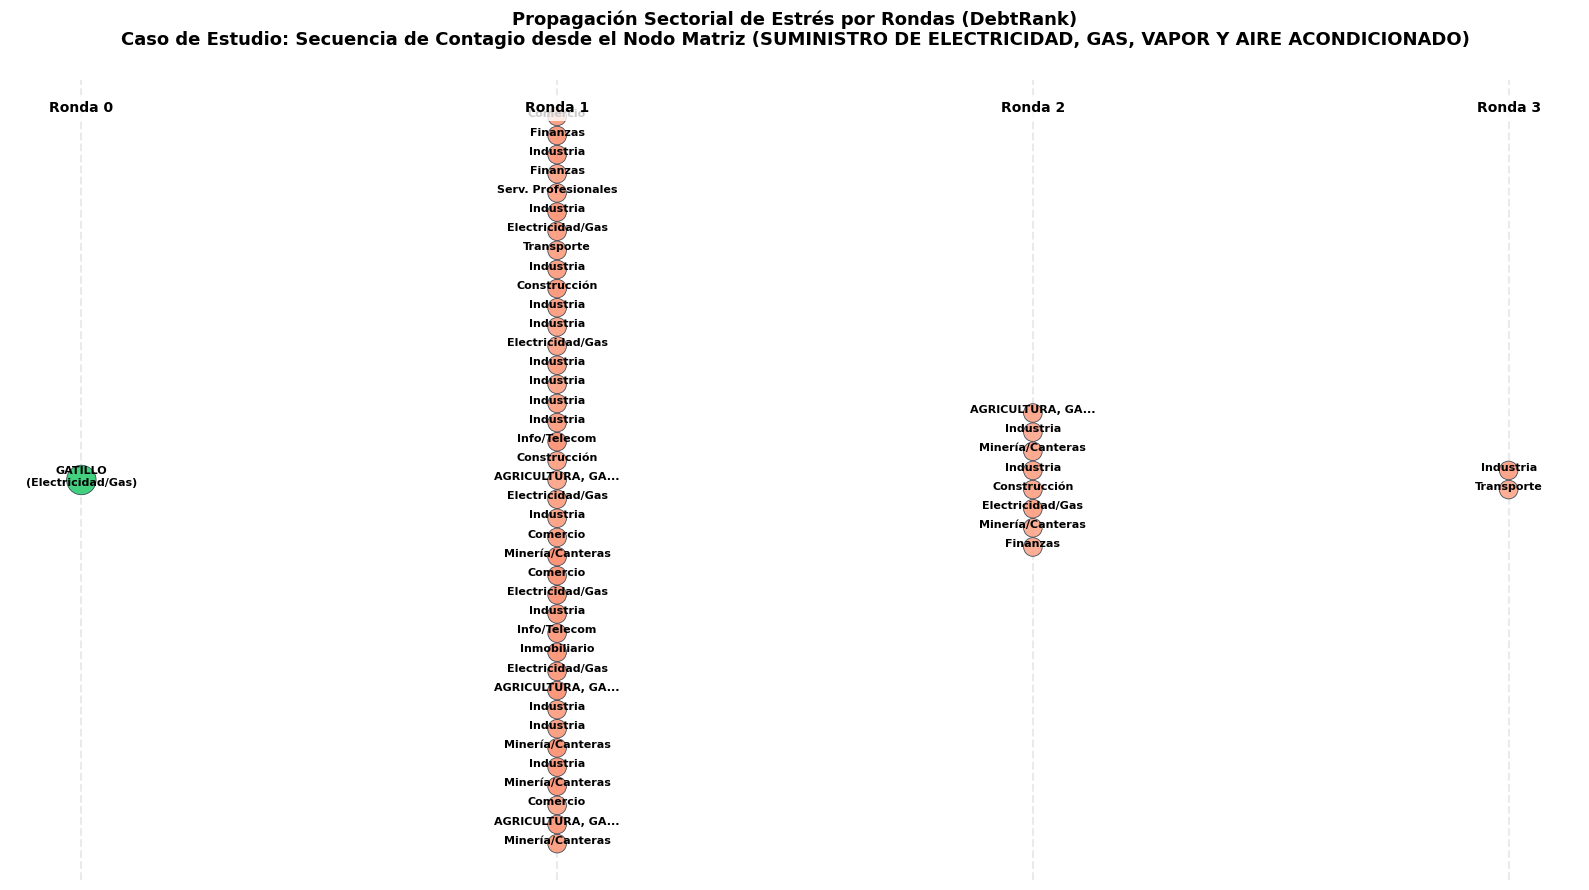

In [163]:
# =====================================================================
# 1. EJECUCIÓN DE LA AUDITORÍA TEMPORAL (OBTENER EL DATAFRAME DE PASOS)
# =====================================================================
# Usamos la función 'auditar_secuencia_contagio' que corrimos en el paso anterior
# sobre tu CUIT número 1 del ranking (por ejemplo, el CUIT de Celulosa o Agrofina)
df_pasos = auditar_secuencia_contagio(G_multi, cuit_lider, actividades_final)

# =====================================================================
# 2. CONSTRUCCIÓN DEL SUBGRAFO DE PROPAGACIÓN JERÁRQUICO
# =====================================================================
# Creamos un nuevo DiGraph limpio para armar el árbol de la cascada
G_arbol = nx.DiGraph()

# Agregamos los nodos con el atributo del paso en el que cayeron
for idx, row in df_pasos.iterrows():
    G_arbol.add_node(
        row["cuit"],
        paso=int(row["Paso_Contagio"]),
        estres=float(row["Estrés_Recibido"]),
        sector=row["descripcion_seccion"],
    )

# Conectamos los nodos basándonos en la red real:
# Una flecha va de A a B si existe en G_multi Y además A cayó justo en el paso anterior a B
for u, v in G_multi.edges():
    if G_arbol.has_node(u) and G_arbol.has_node(v):
        paso_u = G_arbol.nodes[u]["paso"]
        paso_v = G_arbol.nodes[v]["paso"]
        # El estrés viaja cronológicamente hacia adelante
        if paso_v == paso_u + 1:
            G_arbol.add_edge(u, v)

# =====================================================================
# 3. DISEÑO DEL LAYOUT POR COLUMNAS (MÉTODO JERÁRQUICO POR PASOS)
# =====================================================================
pos_jerarquico = {}
# Agrupamos los nodos por su número de paso para calcular sus coordenadas Y
pasos_unicos = sorted(df_pasos["Paso_Contagio"].unique())

for paso in pasos_unicos:
    nodos_del_paso = [
        n for n, attr in G_arbol.nodes(data=True) if attr["paso"] == paso
    ]
    num_nodos = len(nodos_del_paso)

    for idx, nodo in enumerate(nodos_del_paso):
        # Coordenada X = El número de paso (avanza de izquierda a derecha)
        x = paso
        # Coordenada Y = Centrada verticalmente para que quede con forma de árbol/abanico
        y = idx - (num_nodos - 1) / 2.0 if num_nodos > 1 else 0.0
        pos_jerarquico[nodo] = (x, y)

# =====================================================================
# 4. MAPEO VISUAL DE COLORES, TAMAÑOS Y ETIQUETAS SECTORIALES
# =====================================================================
plt.figure(figsize=(16, 9), dpi=100) # Le damos un poquito más de ancho para las etiquetas de texto

node_colors = []
node_sizes = []
labels_sectores = {}

# Diccionario interno para mapear y abreviar nombres larguísimos de AFIP/CLAE
# Si tus nombres ya están limpios, podés omitir o adaptar este mapeo
abreviaciones = {
    "AGRICULTURA, GANADERÍA, CAZA, SILVICULTURE Y PESCA": "Agro",
    "INDUSTRIA MANUFACTURERA": "Industria",
    "SUMINISTRO DE ELECTRICIDAD, GAS, VAPOR Y AIRE ACONDICIONADO": "Electricidad/Gas",
    "COMERCIO AL POR MAYOR Y AL POR MENOR; REPARACIÓN DE VEHÍCULOS": "Comercio",
    "COMERCIO AL POR MAYOR Y AL POR MENOR; REPARACIÓN DE VEHÍCULOS AUTOMOTORES Y MOTOCICLETAS": "Comercio",
    "SERVICIO DE TRANSPORTE Y ALMACENAMIENTO": "Transporte",
    "SERVICIOS FINANCIEROS Y DE SEGUROS": "Finanzas",
    "EXPLOTACIÓN DE MINAS Y CANTERAS": "Minería/Canteras",
    "CONSTRUCCIÓN": "Construcción",
    "INFORMACIÓN Y COMUNICACIONES": "Info/Telecom",
    "SERVICIOS INMOBILIARIOS": "Inmobiliario",
    "SERVICIOS PROFESIONALES, CIENTÍFICOS Y TÉCNICOS": "Serv. Profesionales"
}

for n, attr in G_arbol.nodes(data=True):
    # 4.1 Configuración de colores y tamaños
    if attr["paso"] == 0:
        node_colors.append("#2ecc71")  # Verde esmeralda para el Paciente Cero
        node_sizes.append(450)
    else:
        node_colors.append(cm.Reds(0.3 + 0.7 * attr["estres"]))
        node_sizes.append(180)

    # 4.2 Construcción de la etiqueta limpia por sector
    sector_original = attr["sector"]
    # Buscamos si tenemos una abreviación guardada, si no, dejamos los primeros 15 caracteres
    sector_limpio = abreviaciones.get(sector_original, str(sector_original)[:15] + "...")

    # Armamos la etiqueta. Para el paciente cero podemos dejar una marca distintiva
    if attr["paso"] == 0:
        labels_sectores[n] = f"GATILLO\n({sector_limpio})"
    else:
        labels_sectores[n] = sector_limpio

# Dibujamos las aristas (flechas del dominó)
nx.draw_networkx_edges(
    G_arbol,
    pos_jerarquico,
    edge_color="#e74c3c",
    alpha=0.35,
    width=1.2,
    arrowsize=12,
    node_size=250,
)

# Dibujamos los nodos del árbol
nx.draw_networkx_nodes(
    G_arbol,
    pos_jerarquico,
    node_color=node_colors,
    node_size=node_sizes,
    alpha=0.9,
    edgecolors="#2c3e50",
    linewidths=0.6,
)

# Colocamos las nuevas etiquetas sectoriales desplazadas hacia arriba
# Incrementamos levemente el desplazamiento vertical (0.15) para dar aire al texto
pos_labels = {k: (v[0], v[1] + 0.15) for k, v in pos_jerarquico.items()}
nx.draw_networkx_labels(
    G_arbol,
    pos_labels,
    labels=labels_sectores,
    font_size=8,
    font_weight="bold",
    font_family="sans-serif"
)

# Dibujamos líneas guía verticales de fondo para identificar cada etapa de tiempo
for paso in pasos_unicos:
    plt.axvline(x=paso, color="#b2bec3", linestyle="--", alpha=0.3, zorder=0)
    plt.text(
        paso,
        plt.ylim()[1] * 0.92,
        f"Ronda {paso}",
        horizontalalignment="center",
        fontsize=10,
        fontweight="bold",
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="none"),
    )

# Formateo estético final del lienzo
plt.title(
    f"Propagación Sectorial de Estrés por Rondas (DebtRank)\n"
    f"Caso de Estudio: Secuencia de Contagio desde el Nodo Matriz ({info_gatillo['descripcion_seccion']})",
    fontsize=13,
    fontweight="bold",
    pad=25,
)
plt.axis("off")
plt.tight_layout()

# Guardamos el PDF definitivo optimizado para la lectura de la tesis
plt.savefig(f"debtrank_arbol_sectorial_{cuit_lider}.pdf", bbox_inches="tight", dpi=300)
plt.show()